In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
PROJECT_ROOT = Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
TABLES_DIR = OUTPUTS_DIR / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("TABLES_DIR:", TABLES_DIR)
print("FIGURES_DIR:", FIGURES_DIR)

TABLES_DIR: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/tables
FIGURES_DIR: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures


In [4]:
segment_sync_summary = pd.read_csv(TABLES_DIR / "group_synchrony_segment_summary.csv")
surrogate_test_summary = pd.read_csv(TABLES_DIR / "group_synchrony_surrogate_test_summary.csv")
contrast_df = pd.read_csv(TABLES_DIR / "group_synchrony_main_vs_pre_contrast.csv")
window_sync_df = pd.read_csv(TABLES_DIR / "group_synchrony_sliding_windows.csv")
main_pairwise = pd.read_csv(TABLES_DIR / "main_meditation_pairwise_ranked_winsorized.csv")

display(segment_sync_summary)
display(surrogate_test_summary)
display(contrast_df)
display(main_pairwise.head(10))

,segment,n_timepoints,mean_pairwise_corr_raw,median_pairwise_corr_raw,mean_pairwise_corr_winsorized,median_pairwise_corr_winsorized,cluster_467_mean_corr_raw,cluster_467_mean_corr_winsorized
0,pre_meditation,242,0.004572,0.016992,-0.001011,0.012224,-0.022791,-0.025470
1,main_meditation,752,0.045997,0.036377,0.046693,0.032718,0.194278,0.212368
2,recovery,93,-0.003986,0.000744,0.011486,-0.004488,-0.159217,-0.159539


,segment,observed_whole_group_mean_corr,null_whole_mean,null_whole_std,whole_group_zscore,whole_group_p_upper,observed_cluster_467_mean_corr,null_cluster_mean,null_cluster_std,cluster_467_zscore,cluster_467_p_upper
0,pre_meditation,-0.001011,-0.000219,0.018365,-0.043102,0.500750,-0.025470,-0.001220,0.042961,-0.564465,0.709645
1,main_meditation,0.046693,-0.000312,0.016597,2.832057,0.007996,0.212368,-0.000092,0.060329,3.521653,0.001499
2,recovery,0.011486,0.000659,0.041952,0.258072,0.365317,-0.159539,0.001690,0.080286,-2.008171,0.978011


,metric,observed_main_minus_pre,null_diff_mean,null_diff_std,zscore_main_minus_pre,p_upper_main_greater_pre
0,whole_group_mean_corr,0.047703,-0.000092,0.024853,1.923143,0.032984
1,cluster_467_mean_corr,0.237837,0.001128,0.075104,3.151773,0.001499


,subject_a,subject_b,n_points,corr
0,EmotiBit_4,EmotiBit_7,752,0.230585
1,EmotiBit_6,EmotiBit_7,752,0.213249
2,EmotiBit_4,EmotiBit_6,752,0.193268
3,EmotiBit_3,EmotiBit_4,752,0.070404
4,EmotiBit_2,EmotiBit_4,752,0.059553
5,EmotiBit_3,EmotiBit_6,752,0.036904
6,EmotiBit_1,EmotiBit_7,752,0.032953
7,EmotiBit_1,EmotiBit_6,752,0.032718
8,EmotiBit_2,EmotiBit_7,752,0.029976
9,EmotiBit_1,EmotiBit_4,752,0.027986


In [ ]:
final_summary = segment_sync_summary.merge(
    surrogate_test_summary,
    on="segment",
    how="left"
)

display(final_summary)

,segment,n_timepoints,mean_pairwise_corr_raw,median_pairwise_corr_raw,mean_pairwise_corr_winsorized,median_pairwise_corr_winsorized,cluster_467_mean_corr_raw,cluster_467_mean_corr_winsorized,observed_whole_group_mean_corr,null_whole_mean,null_whole_std,whole_group_zscore,whole_group_p_upper,observed_cluster_467_mean_corr,null_cluster_mean,null_cluster_std,cluster_467_zscore,cluster_467_p_upper
0,pre_meditation,242,0.004572,0.016992,-0.001011,0.012224,-0.022791,-0.025470,-0.001011,-0.000219,0.018365,-0.043102,0.500750,-0.025470,-0.001220,0.042961,-0.564465,0.709645
1,main_meditation,752,0.045997,0.036377,0.046693,0.032718,0.194278,0.212368,0.046693,-0.000312,0.016597,2.832057,0.007996,0.212368,-0.000092,0.060329,3.521653,0.001499
2,recovery,93,-0.003986,0.000744,0.011486,-0.004488,-0.159217,-0.159539,0.011486,0.000659,0.041952,0.258072,0.365317,-0.159539,0.001690,0.080286,-2.008171,0.978011


In [6]:
out_path = TABLES_DIR / "final_synchrony_summary_merged.csv"
final_summary.to_csv(out_path, index=False)
print("Saved:", out_path)

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/tables/final_synchrony_summary_merged.csv


In [7]:
def fmt(x, digits=3):
    if pd.isna(x):
        return "NA"
    return f"{x:.{digits}f}"

def p_fmt(p):
    if pd.isna(p):
        return "NA"
    if p < 0.001:
        return "<0.001"
    return f"{p:.3f}"

In [8]:
pub_table = final_summary[[
    "segment",
    "mean_pairwise_corr_winsorized",
    "cluster_467_mean_corr_winsorized",
    "whole_group_p_upper",
    "cluster_467_p_upper",
]].copy()

pub_table = pub_table.rename(columns={
    "segment": "Segment",
    "mean_pairwise_corr_winsorized": "Whole-group mean r",
    "cluster_467_mean_corr_winsorized": "Cluster 4-6-7 mean r",
    "whole_group_p_upper": "Whole-group p",
    "cluster_467_p_upper": "Cluster 4-6-7 p",
})

display(pub_table)

,Segment,Whole-group mean r,Cluster 4-6-7 mean r,Whole-group p,Cluster 4-6-7 p
0,pre_meditation,-0.001011,-0.025470,0.500750,0.709645
1,main_meditation,0.046693,0.212368,0.007996,0.001499
2,recovery,0.011486,-0.159539,0.365317,0.978011


In [9]:
out_path = TABLES_DIR / "publication_style_synchrony_table.csv"
pub_table.to_csv(out_path, index=False)
print("Saved:", out_path)

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/tables/publication_style_synchrony_table.csv


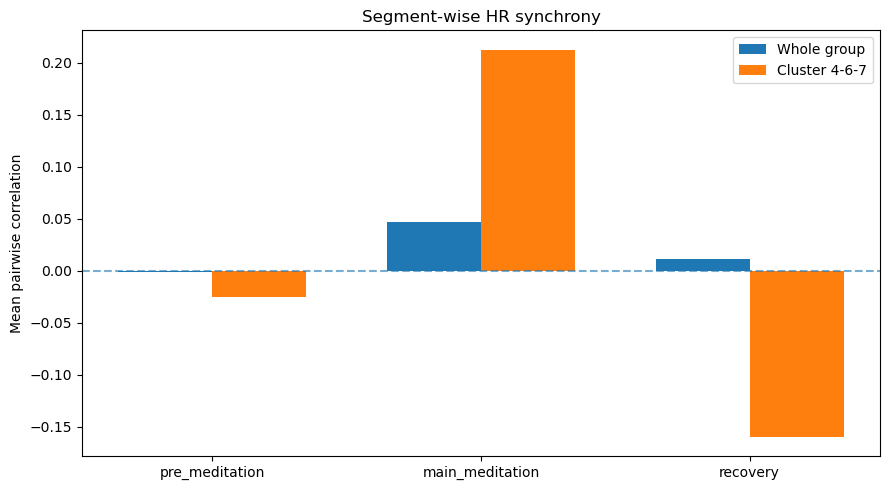

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/final_segmentwise_synchrony_bars.png


In [10]:
plot_df = final_summary.copy()

x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width/2, plot_df["mean_pairwise_corr_winsorized"], width, label="Whole group")
plt.bar(x + width/2, plot_df["cluster_467_mean_corr_winsorized"], width, label="Cluster 4-6-7")

plt.axhline(0, linestyle="--", alpha=0.6)
plt.xticks(x, plot_df["segment"])
plt.ylabel("Mean pairwise correlation")
plt.title("Segment-wise HR synchrony")
plt.legend()
plt.tight_layout()

out_path = FIGURES_DIR / "final_segmentwise_synchrony_bars.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

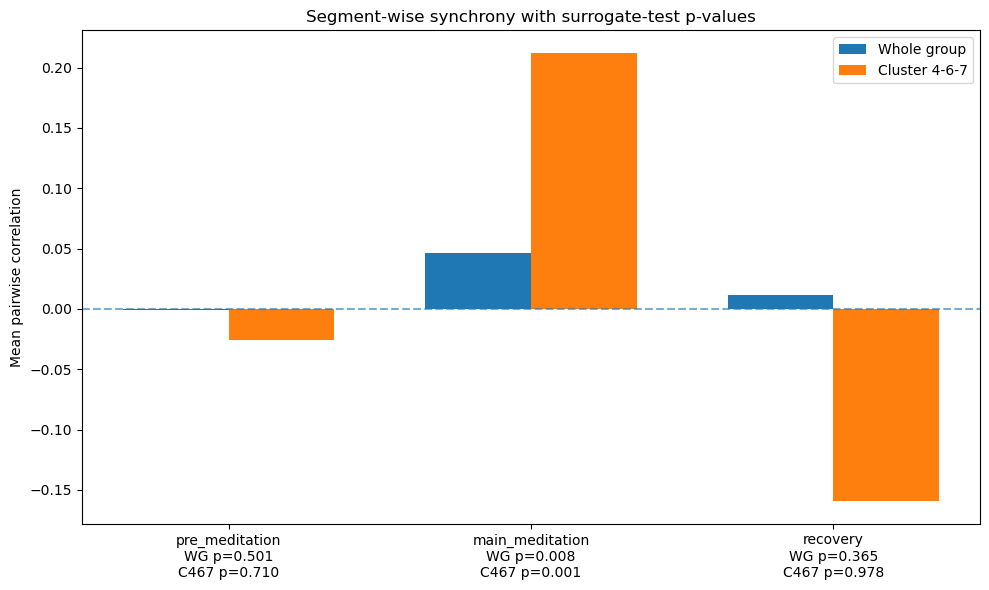

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/final_segmentwise_synchrony_with_pvalues.png


In [11]:
plot_df = final_summary.copy()

labels = []
for _, row in plot_df.iterrows():
    labels.append(
        f"{row['segment']}\nWG p={p_fmt(row['whole_group_p_upper'])}\nC467 p={p_fmt(row['cluster_467_p_upper'])}"
    )

x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, plot_df["mean_pairwise_corr_winsorized"], width, label="Whole group")
plt.bar(x + width/2, plot_df["cluster_467_mean_corr_winsorized"], width, label="Cluster 4-6-7")

plt.axhline(0, linestyle="--", alpha=0.6)
plt.xticks(x, labels)
plt.ylabel("Mean pairwise correlation")
plt.title("Segment-wise synchrony with surrogate-test p-values")
plt.legend()
plt.tight_layout()

out_path = FIGURES_DIR / "final_segmentwise_synchrony_with_pvalues.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

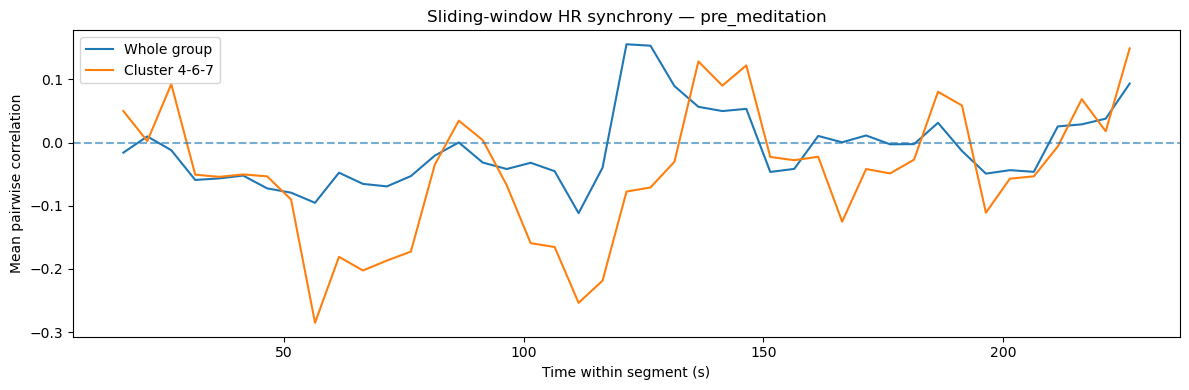

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/final_sliding_window_pre_meditation.png


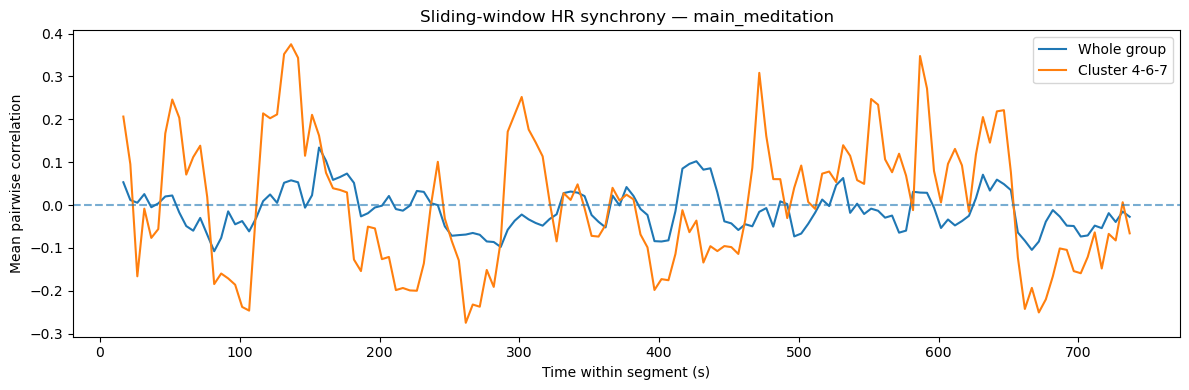

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/final_sliding_window_main_meditation.png


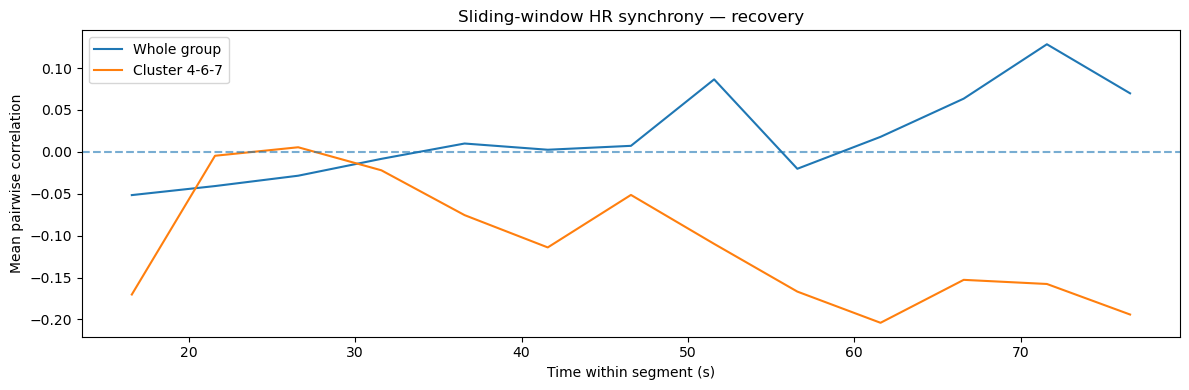

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/final_sliding_window_recovery.png


In [12]:
for segment in ["pre_meditation", "main_meditation", "recovery"]:
    sub = window_sync_df[window_sync_df["segment"] == segment].copy()
    if len(sub) == 0:
        continue

    plt.figure(figsize=(12, 4))
    plt.plot(sub["window_mid"], sub["mean_pairwise_corr"], label="Whole group")
    plt.plot(sub["window_mid"], sub["cluster_467_mean_corr"], label="Cluster 4-6-7")
    plt.axhline(0, linestyle="--", alpha=0.6)

    plt.title(f"Sliding-window HR synchrony — {segment}")
    plt.xlabel("Time within segment (s)")
    plt.ylabel("Mean pairwise correlation")
    plt.legend()
    plt.tight_layout()

    out_path = FIGURES_DIR / f"final_sliding_window_{segment}.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)

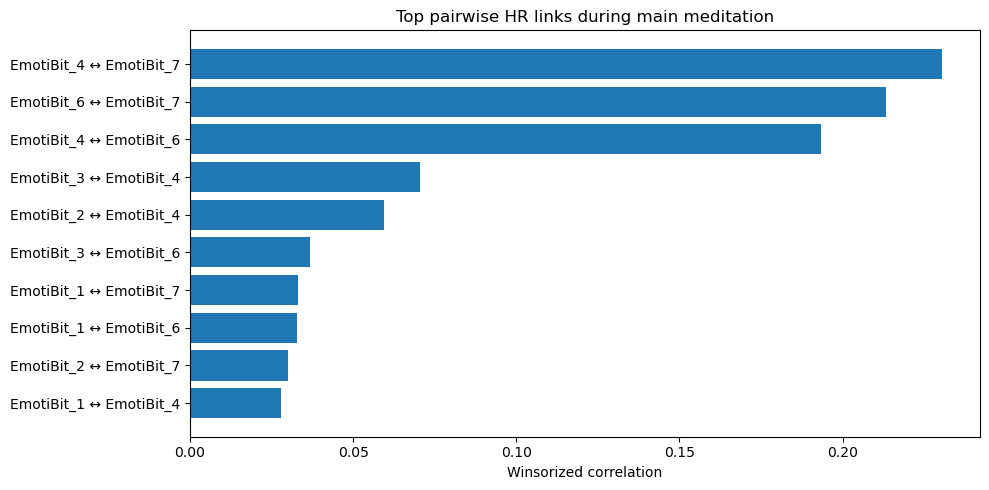

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/final_main_meditation_top_pairs.png


In [13]:
top_n = 10
plot_df = main_pairwise.head(top_n).copy()

pair_labels = plot_df["subject_a"] + " ↔ " + plot_df["subject_b"]

plt.figure(figsize=(10, 5))
plt.barh(pair_labels[::-1], plot_df["corr"].values[::-1])
plt.xlabel("Winsorized correlation")
plt.title("Top pairwise HR links during main meditation")
plt.tight_layout()

out_path = FIGURES_DIR / "final_main_meditation_top_pairs.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

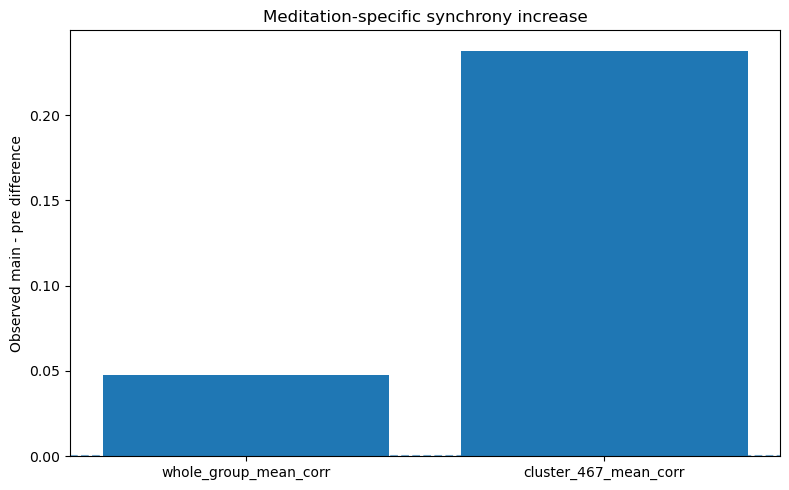

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/final_main_vs_pre_contrast.png


In [14]:
contrast_plot = contrast_df.copy()

plt.figure(figsize=(8, 5))
plt.bar(contrast_plot["metric"], contrast_plot["observed_main_minus_pre"])
plt.axhline(0, linestyle="--", alpha=0.6)
plt.ylabel("Observed main - pre difference")
plt.title("Meditation-specific synchrony increase")
plt.tight_layout()

out_path = FIGURES_DIR / "final_main_vs_pre_contrast.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

In [15]:
narrative_rows = []

for _, row in final_summary.iterrows():
    segment = row["segment"]

    narrative_rows.append({
        "segment": segment,
        "whole_group_result": (
            f"r={fmt(row['mean_pairwise_corr_winsorized'])}, "
            f"p={p_fmt(row['whole_group_p_upper'])}"
        ),
        "cluster_467_result": (
            f"r={fmt(row['cluster_467_mean_corr_winsorized'])}, "
            f"p={p_fmt(row['cluster_467_p_upper'])}"
        ),
    })

narrative_table = pd.DataFrame(narrative_rows)
display(narrative_table)

,segment,whole_group_result,cluster_467_result
0,pre_meditation,"r=-0.001, p=0.501","r=-0.025, p=0.710"
1,main_meditation,"r=0.047, p=0.008","r=0.212, p=0.001"
2,recovery,"r=0.011, p=0.365","r=-0.160, p=0.978"


In [16]:
out_path = TABLES_DIR / "final_synchrony_narrative_table.csv"
narrative_table.to_csv(out_path, index=False)
print("Saved:", out_path)

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/tables/final_synchrony_narrative_table.csv


In [17]:
pre_row = final_summary[final_summary["segment"] == "pre_meditation"].iloc[0]
main_row = final_summary[final_summary["segment"] == "main_meditation"].iloc[0]
rec_row = final_summary[final_summary["segment"] == "recovery"].iloc[0]

cluster_contrast = contrast_df[contrast_df["metric"] == "cluster_467_mean_corr"].iloc[0]
whole_contrast = contrast_df[contrast_df["metric"] == "whole_group_mean_corr"].iloc[0]

summary_text = f"""
Final interpretation

Pre-meditation showed no evidence of HR synchrony at either the whole-group or subgroup level.
Whole-group synchrony was {fmt(pre_row['mean_pairwise_corr_winsorized'])} (p={p_fmt(pre_row['whole_group_p_upper'])}),
and cluster 4-6-7 synchrony was {fmt(pre_row['cluster_467_mean_corr_winsorized'])} (p={p_fmt(pre_row['cluster_467_p_upper'])}).

During main meditation, whole-group synchrony increased slightly above the circular-shift null
(r={fmt(main_row['mean_pairwise_corr_winsorized'])}, p={p_fmt(main_row['whole_group_p_upper'])}),
but the clearest effect was a subgroup pattern in EmotiBit 4, 6, and 7
(r={fmt(main_row['cluster_467_mean_corr_winsorized'])}, p={p_fmt(main_row['cluster_467_p_upper'])}).

The meditation-specific increase from pre to main was modest for the whole group
(diff={fmt(whole_contrast['observed_main_minus_pre'])}, p={p_fmt(whole_contrast['p_upper_main_greater_pre'])}),
but strong for the 4-6-7 subgroup
(diff={fmt(cluster_contrast['observed_main_minus_pre'])}, p={p_fmt(cluster_contrast['p_upper_main_greater_pre'])}).

Recovery did not show positive synchrony. Whole-group synchrony returned near zero
(r={fmt(rec_row['mean_pairwise_corr_winsorized'])}, p={p_fmt(rec_row['whole_group_p_upper'])}),
while the 4-6-7 subgroup shifted negative
(r={fmt(rec_row['cluster_467_mean_corr_winsorized'])}, p={p_fmt(rec_row['cluster_467_p_upper'])} for positive-tail testing).

Overall, the data support weak whole-group coupling but a clearer, meditation-specific and transient subgroup synchrony effect in participants 4, 6, and 7.
""".strip()

print(summary_text)

Final interpretation

Pre-meditation showed no evidence of HR synchrony at either the whole-group or subgroup level.
Whole-group synchrony was -0.001 (p=0.501),
and cluster 4-6-7 synchrony was -0.025 (p=0.710).

During main meditation, whole-group synchrony increased slightly above the circular-shift null
(r=0.047, p=0.008),
but the clearest effect was a subgroup pattern in EmotiBit 4, 6, and 7
(r=0.212, p=0.001).

The meditation-specific increase from pre to main was modest for the whole group
(diff=0.048, p=0.033),
but strong for the 4-6-7 subgroup
(diff=0.238, p=0.001).

Recovery did not show positive synchrony. Whole-group synchrony returned near zero
(r=0.011, p=0.365),
while the 4-6-7 subgroup shifted negative
(r=-0.160, p=0.978 for positive-tail testing).

Overall, the data support weak whole-group coupling but a clearer, meditation-specific and transient subgroup synchrony effect in participants 4, 6, and 7.


In [18]:
out_path = TABLES_DIR / "final_synchrony_interpretation.txt"
with open(out_path, "w", encoding="utf-8") as f:
    f.write(summary_text)

print("Saved:", out_path)

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/tables/final_synchrony_interpretation.txt


In [19]:
slide_bullets = [
    "Pre-meditation HR synchrony was absent at both the whole-group and subgroup levels.",
    "Main meditation showed a small but significant whole-group synchrony increase above null.",
    "The strongest effect was a subgroup consisting of EmotiBit 4, 6, and 7.",
    "This subgroup showed moderate positive HR synchrony during meditation (r≈0.21).",
    "The subgroup main-vs-pre increase was strongly significant under circular-shift surrogate testing.",
    "Recovery did not show positive synchrony, suggesting the effect was meditation-specific.",
    "Sliding-window analysis showed transient bursts of subgroup synchrony rather than steady coupling.",
]

for i, bullet in enumerate(slide_bullets, start=1):
    print(f"{i}. {bullet}")

1. Pre-meditation HR synchrony was absent at both the whole-group and subgroup levels.
2. Main meditation showed a small but significant whole-group synchrony increase above null.
3. The strongest effect was a subgroup consisting of EmotiBit 4, 6, and 7.
4. This subgroup showed moderate positive HR synchrony during meditation (r≈0.21).
5. The subgroup main-vs-pre increase was strongly significant under circular-shift surrogate testing.
6. Recovery did not show positive synchrony, suggesting the effect was meditation-specific.
7. Sliding-window analysis showed transient bursts of subgroup synchrony rather than steady coupling.


In [20]:
out_path = TABLES_DIR / "final_synchrony_slide_bullets.txt"
with open(out_path, "w", encoding="utf-8") as f:
    for i, bullet in enumerate(slide_bullets, start=1):
        f.write(f"{i}. {bullet}\n")

print("Saved:", out_path)

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/tables/final_synchrony_slide_bullets.txt


In [21]:
compact_rows = []

for _, row in final_summary.iterrows():
    compact_rows.append({
        "Segment": row["segment"],
        "Whole-group r": fmt(row["mean_pairwise_corr_winsorized"]),
        "Whole-group p": p_fmt(row["whole_group_p_upper"]),
        "Cluster 4-6-7 r": fmt(row["cluster_467_mean_corr_winsorized"]),
        "Cluster 4-6-7 p": p_fmt(row["cluster_467_p_upper"]),
    })

compact_final_table = pd.DataFrame(compact_rows)
display(compact_final_table)

,Segment,Whole-group r,Whole-group p,Cluster 4-6-7 r,Cluster 4-6-7 p
0,pre_meditation,-0.001,0.501,-0.025,0.710
1,main_meditation,0.047,0.008,0.212,0.001
2,recovery,0.011,0.365,-0.160,0.978


In [22]:
out_path = TABLES_DIR / "compact_final_synchrony_table.csv"
compact_final_table.to_csv(out_path, index=False)
print("Saved:", out_path)

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/tables/compact_final_synchrony_table.csv


In [23]:
print("=== FINAL SYNCHRONY RESULTS NOTEBOOK COMPLETE ===")
print("Created:")
print("- merged final summary tables")
print("- segment-wise synchrony bar plots")
print("- sliding-window synchrony plots")
print("- top pairwise main-meditation plot")
print("- contrast plot")
print("- interpretation text")
print("- slide-ready bullets")

=== FINAL SYNCHRONY RESULTS NOTEBOOK COMPLETE ===
Created:
- merged final summary tables
- segment-wise synchrony bar plots
- sliding-window synchrony plots
- top pairwise main-meditation plot
- contrast plot
- interpretation text
- slide-ready bullets
